In [148]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [149]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset Paths

The dataset contains an `Images` folder inside `indoorCVPR_09`.

The training and testing image lists are stored separately as:

- TrainImages.txt
- TestImages.txt

In [150]:
dataset_path = Path(r"F:\Anas\Dataset\Object_Data")

image_path = dataset_path / "indoorCVPR_09" / "Images"

train_file = dataset_path / "TrainImages.txt"

test_file = dataset_path / "TestImages.txt"

print("Dataset path:")
print(dataset_path)

print("\nImage path:")
print(image_path)

print("\nTrain file:")
print(train_file)

print("\nTest file:")
print(test_file)

Dataset path:
F:\Anas\Dataset\Object_Data

Image path:
F:\Anas\Dataset\Object_Data\indoorCVPR_09\Images

Train file:
F:\Anas\Dataset\Object_Data\TrainImages.txt

Test file:
F:\Anas\Dataset\Object_Data\TestImages.txt


In [151]:
print("Dataset exists:", dataset_path.exists())
print("Images folder exists:", image_path.exists())
print("Train file exists:", train_file.exists())
print("Test file exists:", test_file.exists())

Dataset exists: True
Images folder exists: True
Train file exists: True
Test file exists: True


In [152]:
print("Folders inside Images:\n")

for folder in image_path.iterdir():

    if folder.is_dir():
        print(folder.name)

Folders inside Images:

airport_inside
artstudio
auditorium
bakery
bar
bathroom
bedroom
bookstore
bowling
buffet
casino
children_room
church_inside
classroom
cloister
closet
clothingstore
computerroom
concert_hall
corridor
deli
dentaloffice
dining_room
elevator
fastfood_restaurant
florist
gameroom
garage
greenhouse
grocerystore
gym
hairsalon
hospitalroom
inside_bus
inside_subway
jewelleryshop
kindergarden
kitchen
laboratorywet
laundromat
library
livingroom
lobby
locker_room
mall
meeting_room
movietheater
museum
nursery
office
operating_room
pantry
poolinside
prisoncell
restaurant
restaurant_kitchen
shoeshop
stairscase
studiomusic
subway
toystore
trainstation
tv_studio
videostore
waitingroom
warehouse
winecellar


In [153]:
classes = sorted([
    folder.name
    for folder in image_path.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))

print("\nClasses:")

for i, class_name in enumerate(classes):

    print(i, ":", class_name)

Number of classes: 67

Classes:
0 : airport_inside
1 : artstudio
2 : auditorium
3 : bakery
4 : bar
5 : bathroom
6 : bedroom
7 : bookstore
8 : bowling
9 : buffet
10 : casino
11 : children_room
12 : church_inside
13 : classroom
14 : cloister
15 : closet
16 : clothingstore
17 : computerroom
18 : concert_hall
19 : corridor
20 : deli
21 : dentaloffice
22 : dining_room
23 : elevator
24 : fastfood_restaurant
25 : florist
26 : gameroom
27 : garage
28 : greenhouse
29 : grocerystore
30 : gym
31 : hairsalon
32 : hospitalroom
33 : inside_bus
34 : inside_subway
35 : jewelleryshop
36 : kindergarden
37 : kitchen
38 : laboratorywet
39 : laundromat
40 : library
41 : livingroom
42 : lobby
43 : locker_room
44 : mall
45 : meeting_room
46 : movietheater
47 : museum
48 : nursery
49 : office
50 : operating_room
51 : pantry
52 : poolinside
53 : prisoncell
54 : restaurant
55 : restaurant_kitchen
56 : shoeshop
57 : stairscase
58 : studiomusic
59 : subway
60 : toystore
61 : trainstation
62 : tv_studio
63 : video

In [154]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

In [155]:
print("Class to index:")
print(class_to_index)

Class to index:
{'airport_inside': 0, 'artstudio': 1, 'auditorium': 2, 'bakery': 3, 'bar': 4, 'bathroom': 5, 'bedroom': 6, 'bookstore': 7, 'bowling': 8, 'buffet': 9, 'casino': 10, 'children_room': 11, 'church_inside': 12, 'classroom': 13, 'cloister': 14, 'closet': 15, 'clothingstore': 16, 'computerroom': 17, 'concert_hall': 18, 'corridor': 19, 'deli': 20, 'dentaloffice': 21, 'dining_room': 22, 'elevator': 23, 'fastfood_restaurant': 24, 'florist': 25, 'gameroom': 26, 'garage': 27, 'greenhouse': 28, 'grocerystore': 29, 'gym': 30, 'hairsalon': 31, 'hospitalroom': 32, 'inside_bus': 33, 'inside_subway': 34, 'jewelleryshop': 35, 'kindergarden': 36, 'kitchen': 37, 'laboratorywet': 38, 'laundromat': 39, 'library': 40, 'livingroom': 41, 'lobby': 42, 'locker_room': 43, 'mall': 44, 'meeting_room': 45, 'movietheater': 46, 'museum': 47, 'nursery': 48, 'office': 49, 'operating_room': 50, 'pantry': 51, 'poolinside': 52, 'prisoncell': 53, 'restaurant': 54, 'restaurant_kitchen': 55, 'shoeshop': 56, 'st

In [156]:
with open(train_file, "r") as f:

    train_lines = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("Number of training images:", len(train_lines))

print("\nFirst 10 training images:")

for line in train_lines[:10]:

    print(line)

Number of training images: 5360

First 10 training images:
gameroom/bt_132294gameroom2.jpg
poolinside/inside_pool_and_hot_tub.jpg
winecellar/bodega_12_11_flickr.jpg
casino/casino_0512.jpg
livingroom/living58.jpg
mall/4984307.jpg
corridor/pasilltmpo_t.jpg
laboratorywet/laboratorio_quimica_07_05_altavista.jpg
bookstore/CIMG2743.jpg
casino/casino_0044.jpg


In [157]:
with open(test_file, "r") as f:

    test_lines = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("Number of test images:", len(test_lines))

print("\nFirst 10 test images:")

for line in test_lines[:10]:

    print(line)

Number of test images: 1340

First 10 test images:
kitchen/int474.jpg
operating_room/operating_room_31_03_altavista.jpg
restaurant_kitchen/restaurant_kitchen_google_0075.jpg
videostore/videoclub_05_14_flickr.jpg
poolinside/piscine_interieureee.jpg
videostore/blockbuster_08_10_flickr.jpg
poolinside/piscina_cubierta_07_19_altavista.jpg
mall/mall26.jpg
kindergarden/toddler.jpg
buffet/Buffet_1.jpg


In [158]:
first_image = train_lines[0]

actual_path = image_path / first_image

print("Relative path:")
print(first_image)

print("\nActual path:")
print(actual_path)

print("\nImage exists:", actual_path.exists())

Relative path:
gameroom/bt_132294gameroom2.jpg

Actual path:
F:\Anas\Dataset\Object_Data\indoorCVPR_09\Images\gameroom\bt_132294gameroom2.jpg

Image exists: True


In [159]:
image = Image.open(actual_path).convert("RGB")

print("Image size:", image.size)

print("Image mode:", image.mode)

Image size: (397, 296)
Image mode: RGB


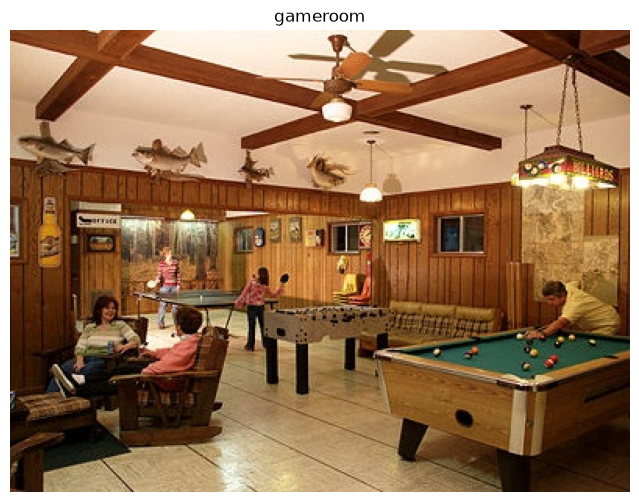

In [160]:
plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.title(first_image.split("/")[0])

plt.axis("off")

plt.show()

In [161]:
train_data = []

for relative_path in train_lines:

    # Get class name
    class_name = Path(relative_path).parts[0]

    # Get complete image path
    full_path = image_path / relative_path

    # Convert class name to number
    label = class_to_index[class_name]

    train_data.append([
        str(full_path),
        class_name,
        label
    ])

In [162]:
train_df = pd.DataFrame(
    train_data,
    columns=[
        "image_path",
        "class_name",
        "label"
    ]
)

In [163]:
train_df.head()

,image_path,class_name,label
0,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,gameroom,26
1,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,poolinside,52
2,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,winecellar,66
3,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,casino,10
4,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,livingroom,41


In [164]:
print("Training images:", len(train_df))

print("\nColumns:")
print(train_df.columns)

print("\nDataset shape:")
print(train_df.shape)

Training images: 5360

Columns:
Index(['image_path', 'class_name', 'label'], dtype='str')

Dataset shape:
(5360, 3)


In [165]:
test_data = []

for relative_path in test_lines:

    class_name = Path(relative_path).parts[0]

    full_path = image_path / relative_path

    label = class_to_index[class_name]

    test_data.append([
        str(full_path),
        class_name,
        label
    ])

In [166]:
test_df = pd.DataFrame(
    test_data,
    columns=[
        "image_path",
        "class_name",
        "label"
    ]
)

In [167]:
print("Testing images:", len(test_df))

test_df.head()

Testing images: 1340


,image_path,class_name,label
0,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,kitchen,37
1,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,operating_room,50
2,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,restaurant_kitchen,55
3,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,videostore,63
4,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,poolinside,52


In [168]:
train_df["exists"] = train_df["image_path"].apply(
    lambda x: Path(x).exists()
)

test_df["exists"] = test_df["image_path"].apply(
    lambda x: Path(x).exists()
)

print(
    "Missing training images:",
    (~train_df["exists"]).sum()
)

print(
    "Missing testing images:",
    (~test_df["exists"]).sum()
)

Missing training images: 0
Missing testing images: 0


In [169]:
train_df.drop(columns=["exists"], inplace=True)

test_df.drop(columns=["exists"], inplace=True)

In [170]:
class_counts = train_df["class_name"].value_counts()

print(class_counts)

class_name
fastfood_restaurant    83
clothingstore          82
garage                 82
tv_studio              82
bathroom               82
                       ..
toystore               78
meeting_room           78
inside_bus             77
restaurant_kitchen     77
museum                 77
Name: count, Length: 67, dtype: int64


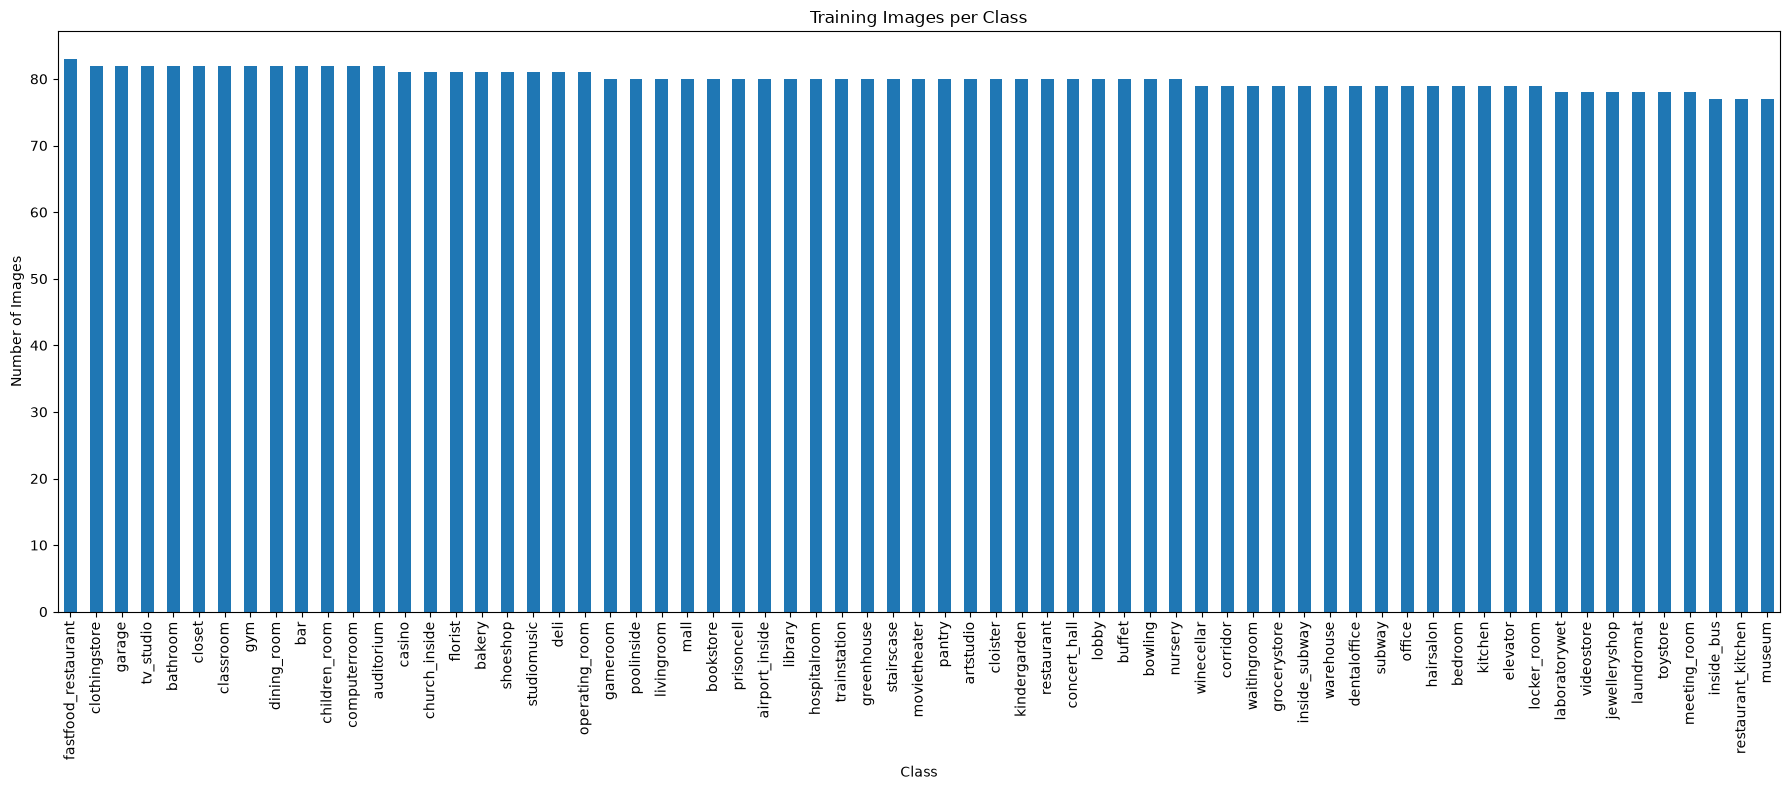

In [171]:
plt.figure(figsize=(18, 8))

class_counts.plot(kind="bar")

plt.title("Training Images per Class")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

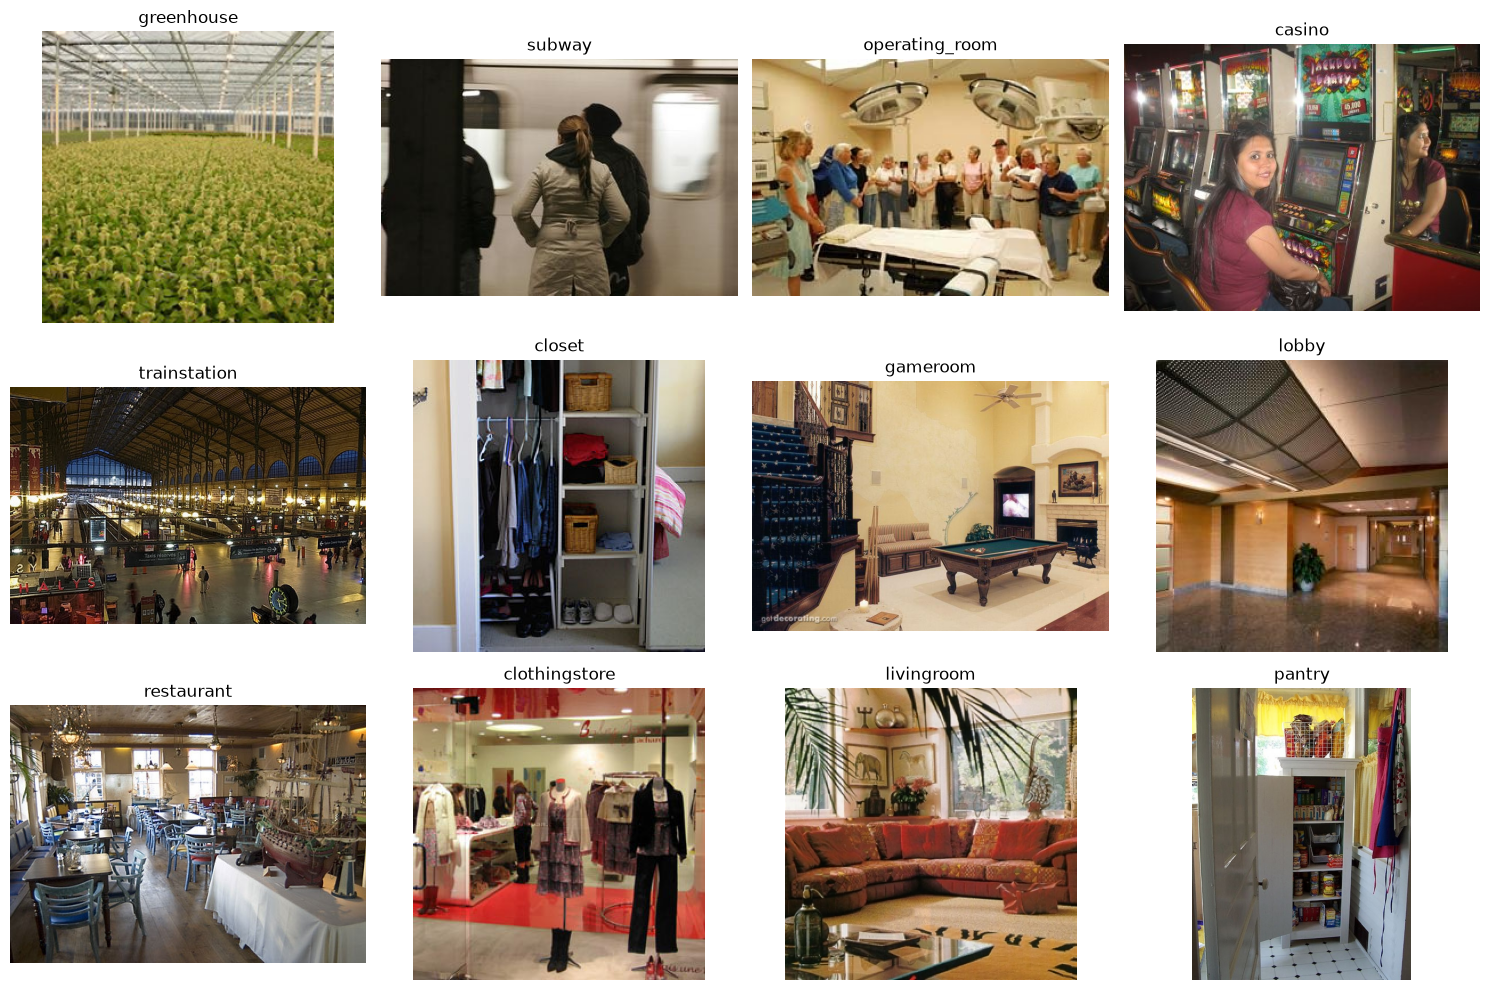

In [172]:
sample_df = train_df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(row["class_name"])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [173]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

In [174]:
print("Training samples:", len(train_df))

print("Validation samples:", len(val_df))

print("Testing samples:", len(test_df))

Training samples: 4288
Validation samples: 1072
Testing samples: 1340


In [175]:
IMG_SIZE = (128, 128)

BATCH_SIZE = 32

NUM_CLASSES = len(classes)

print("Image size:", IMG_SIZE)

print("Batch size:", BATCH_SIZE)

print("Number of classes:", NUM_CLASSES)

Image size: (128, 128)
Batch size: 32
Number of classes: 67


In [176]:
def load_image(image_path, label):

    def read_with_pil(path):
        path = path.numpy().decode("utf-8")

        image = Image.open(path).convert("RGB")
        image = image.resize(IMG_SIZE)

        image = np.array(image, dtype=np.float32) / 255.0

        return image

    image = tf.py_function(
        func=read_with_pil,
        inp=[image_path],
        Tout=tf.float32
    )

    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])

    return image, label

In [177]:
def create_dataset(df, shuffle=False):

    paths = df["image_path"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [178]:
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)

In [179]:
images, labels = next(
    iter(train_dataset)
)

print("Images shape:", images.shape)

print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


In [180]:
for images, labels in train_dataset:
    pass

print("✅ Training dataset works!")

✅ Training dataset works!


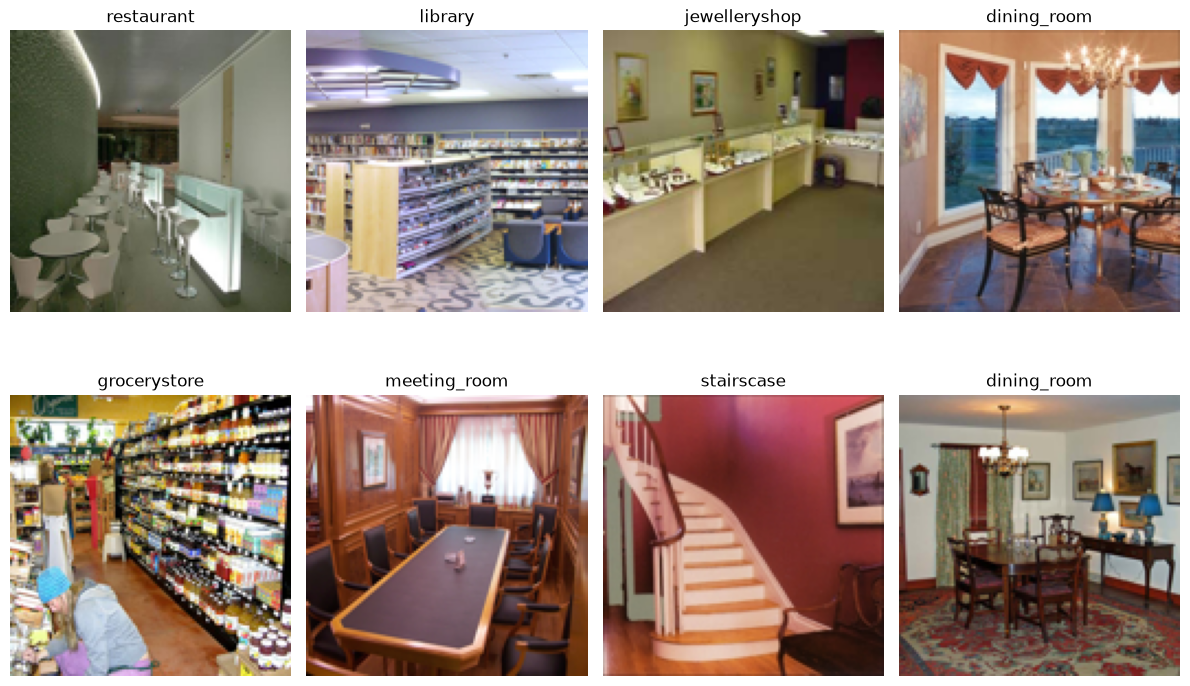

In [181]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    label = labels[i].numpy()

    plt.title(
        index_to_class[label]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [182]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.1
    ),

    tf.keras.layers.RandomZoom(
        0.1
    )
])

In [183]:
model = tf.keras.Sequential([

    # Data augmentation
    data_augmentation,


    # -------------------------
    # Convolution Block 1
    # -------------------------

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    # -------------------------
    # Convolution Block 2
    # -------------------------

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    # -------------------------
    # Convolution Block 3
    # -------------------------

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    # -------------------------
    # Convolution Block 4
    # -------------------------

    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    # -------------------------
    # Classification
    # -------------------------

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.5
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [184]:
model.build(
    input_shape=(
        None,
        128,
        128,
        3
    )
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 67)             │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,600,195 (17.55 MB)

 Trainable params: 4,600,195 (17.55 MB)

 Non-trainable params: 0 (0.00 B)

In [185]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [186]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [187]:
history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=20,

    callbacks=callbacks
)

Epoch 1/20


f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.0093 - loss: 4.2118 - val_accuracy: 0.0149 - val_loss: 4.2046
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.0170 - loss: 4.1945 - val_accuracy: 0.0168 - val_loss: 4.1918
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 132ms/step - accuracy: 0.0261 - loss: 4.1484 - val_accuracy: 0.0280 - val_loss: 4.1275
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.0312 - loss: 4.1021 - val_accuracy: 0.0401 - val_loss: 4.0744
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.0389 - loss: 4.0478 - val_accuracy: 0.0448 - val_loss: 4.0462
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.0424 - loss: 4.0138 - val_accuracy: 0.0494 - val_loss: 4.0177
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.0564 - loss: 3.9927 - val_accuracy: 0.0578 - val_loss: 4.0190
Epoch 8/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.0536 - loss: 3.9586 - val

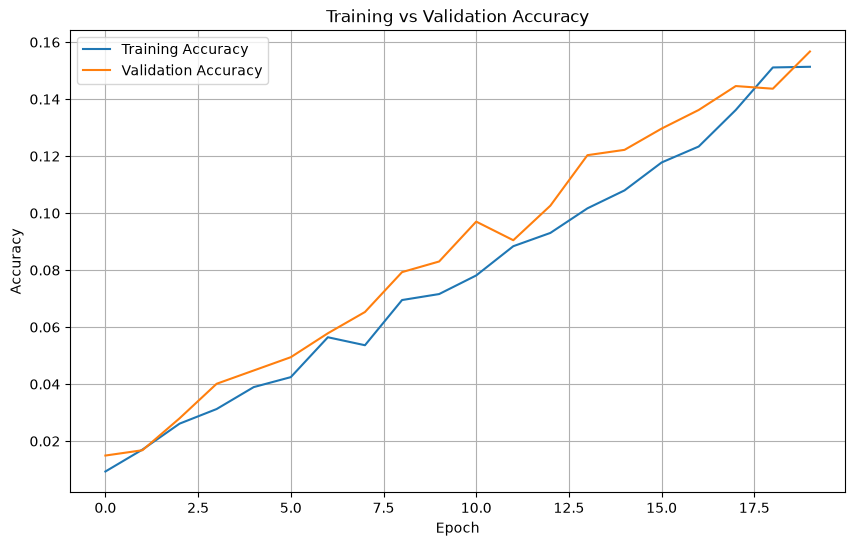

In [188]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

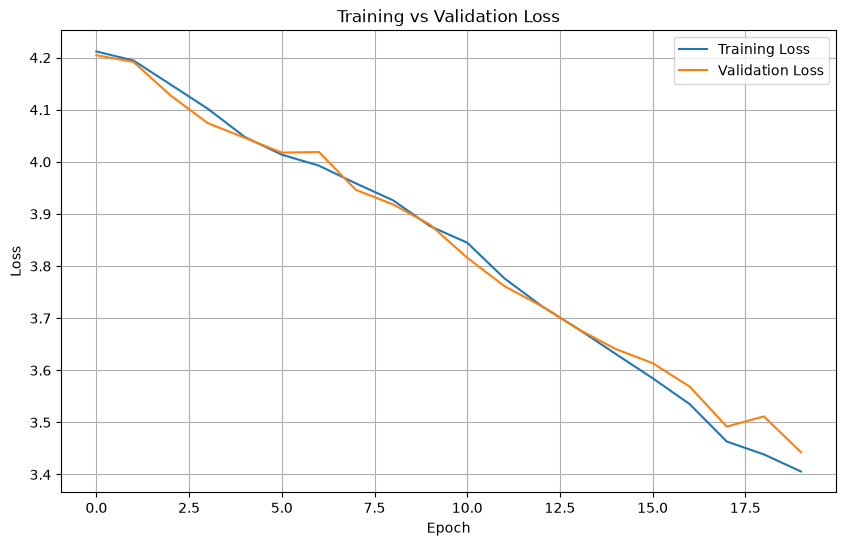

In [189]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [190]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy:",
    test_accuracy
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - accuracy: 0.1485 - loss: 3.4576
Test Loss: 3.4576263427734375
Test Accuracy: 0.14850746095180511


In [191]:
y_true = []

y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)

y_pred = np.array(y_pred)

print("True labels:", y_true.shape)

print("Predicted labels:", y_pred.shape)

True labels: (1340,)
Predicted labels: (1340,)


In [192]:
report = classification_report(

    y_true,

    y_pred,

    target_names=classes,

    zero_division=0
)

print(report)

                     precision    recall  f1-score   support

     airport_inside       0.00      0.00      0.00        20
          artstudio       0.00      0.00      0.00        20
         auditorium       0.12      0.17      0.14        18
             bakery       0.00      0.00      0.00        19
                bar       0.09      0.11      0.10        18
           bathroom       0.08      0.11      0.09        18
            bedroom       0.00      0.00      0.00        21
          bookstore       0.00      0.00      0.00        20
            bowling       0.33      0.15      0.21        20
             buffet       0.12      0.20      0.15        20
             casino       0.26      0.47      0.33        19
      children_room       0.15      0.11      0.13        18
      church_inside       0.15      0.42      0.22        19
          classroom       0.19      0.56      0.28        18
           cloister       0.37      0.55      0.44        20
             closet    

In [193]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (67, 67)


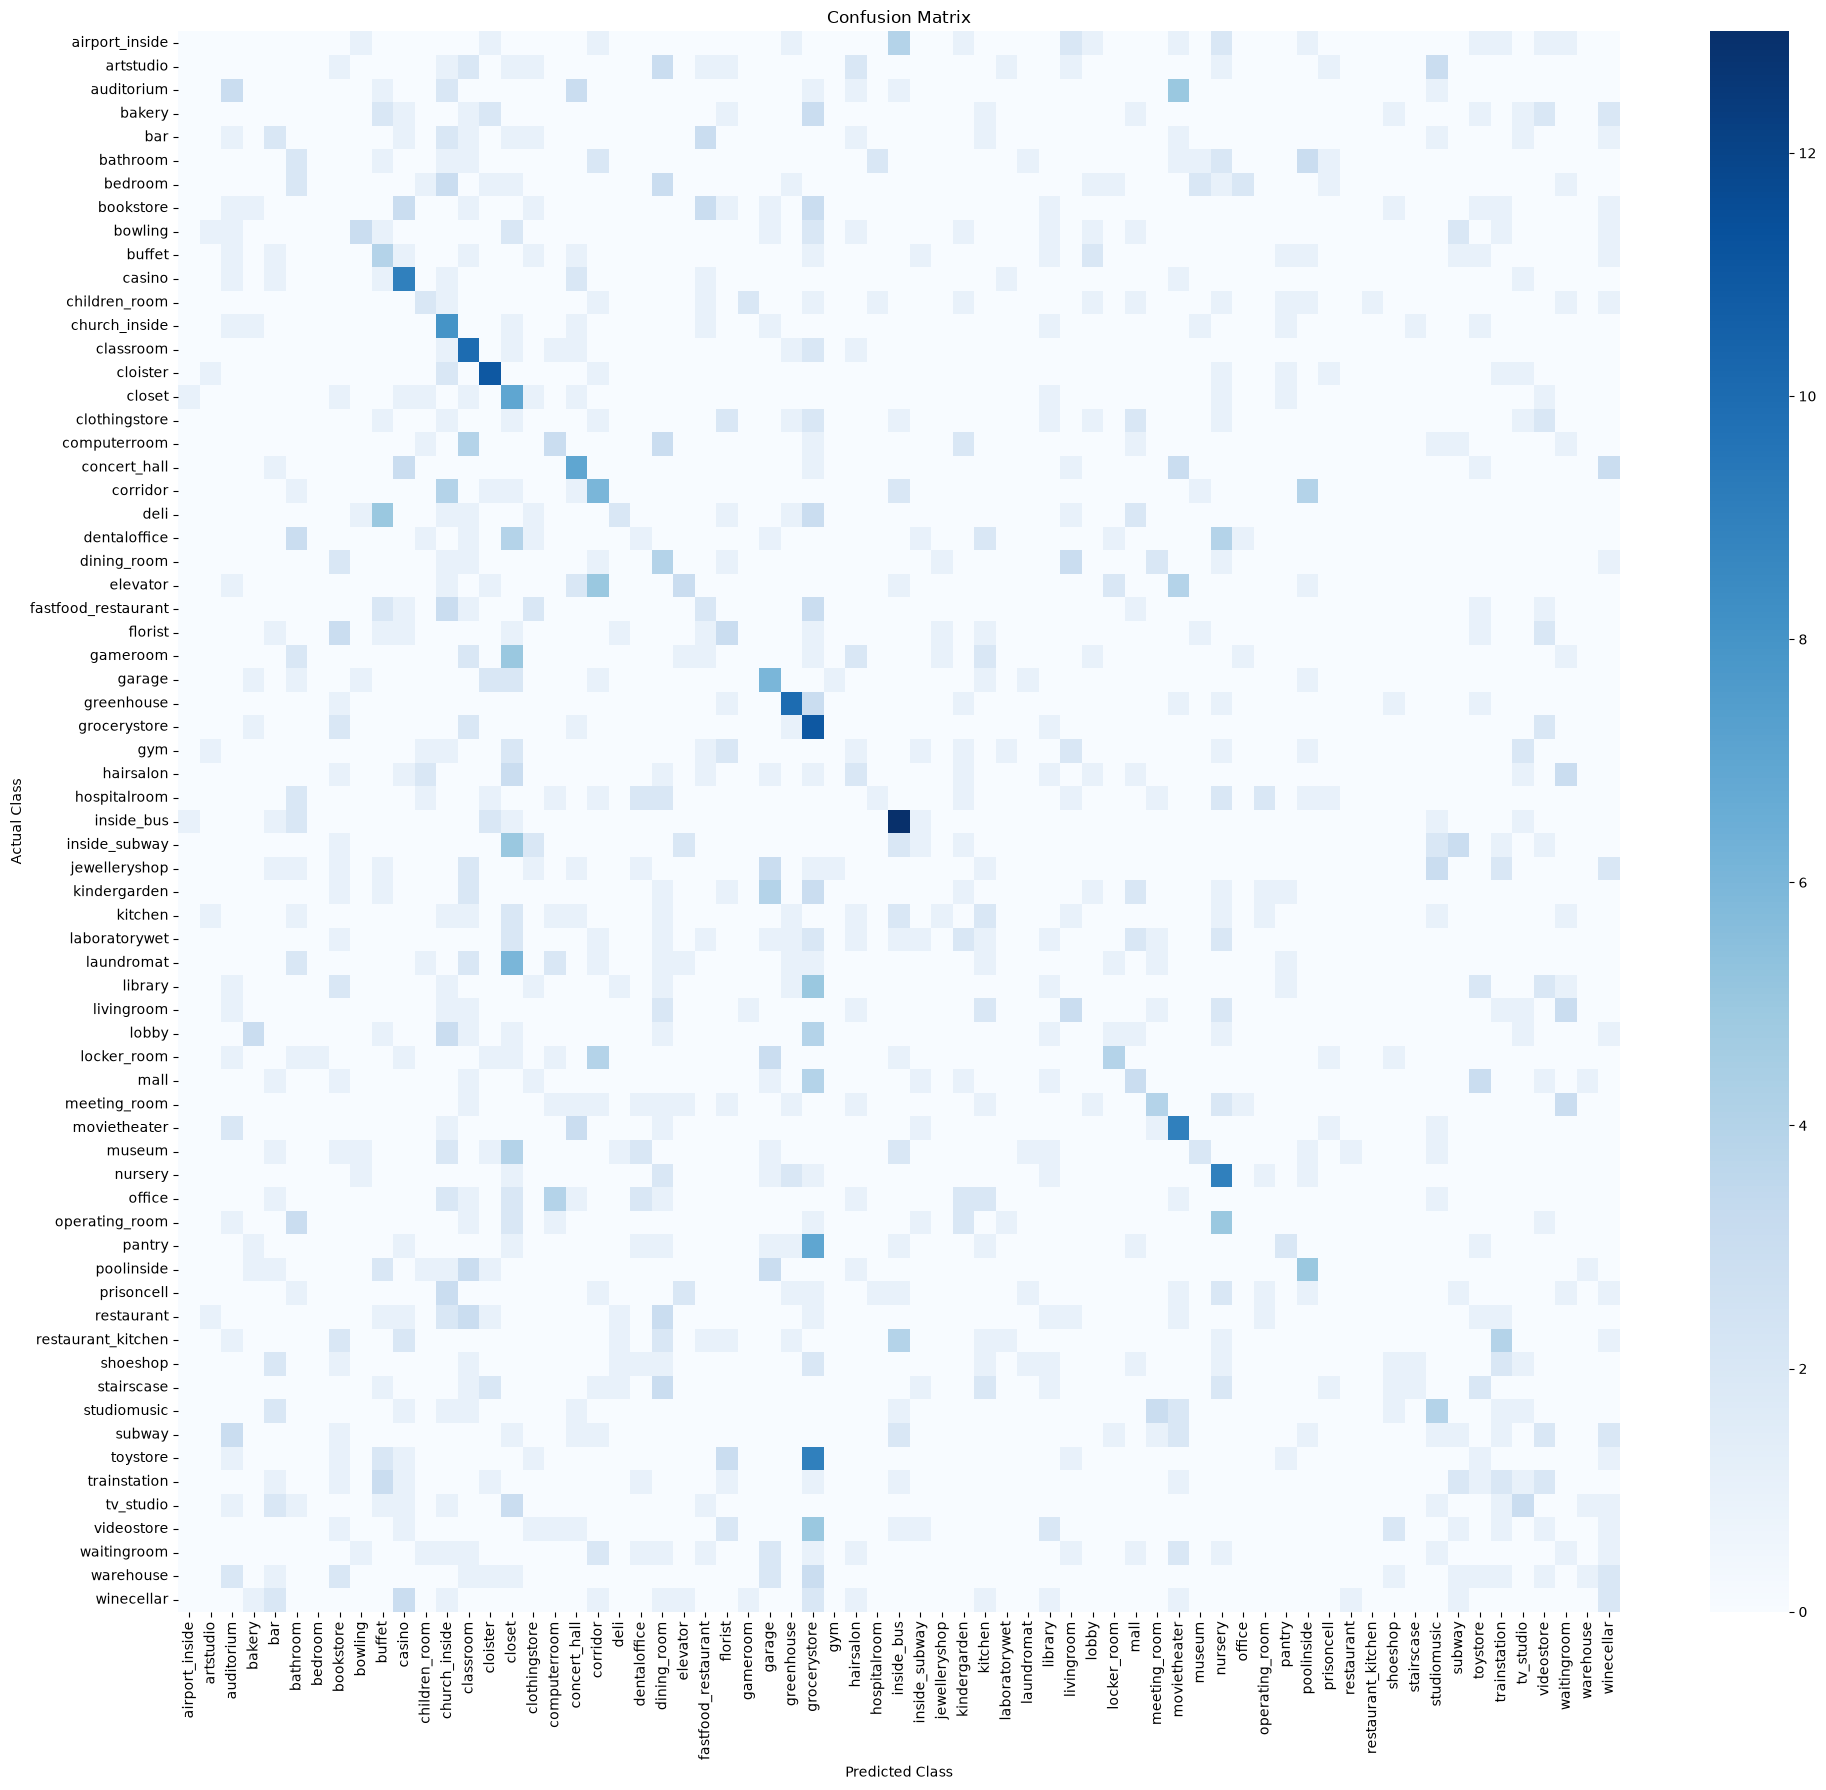

In [194]:
plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [195]:
def predict_image(image_file):

    # Read image
    image = tf.io.read_file(
        image_file
    )

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Normalize
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    # Add batch dimension
    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    # Prediction
    prediction = model.predict(
        image_batch,
        verbose=0
    )

    # Get highest probability
    predicted_index = np.argmax(
        prediction[0]
    )

    # Confidence
    confidence = prediction[0][
        predicted_index
    ]

    # Class name
    predicted_class = index_to_class[
        predicted_index
    ]

    return predicted_class, confidence

In [196]:
sample_image = test_df.iloc[0]["image_path"]

predicted_class, confidence = predict_image(
    sample_image
)

actual_class = test_df.iloc[0]["class_name"]

print("Actual class:", actual_class)

print("Predicted class:", predicted_class)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

Actual class: kitchen
Predicted class: closet
Confidence: 12.58%


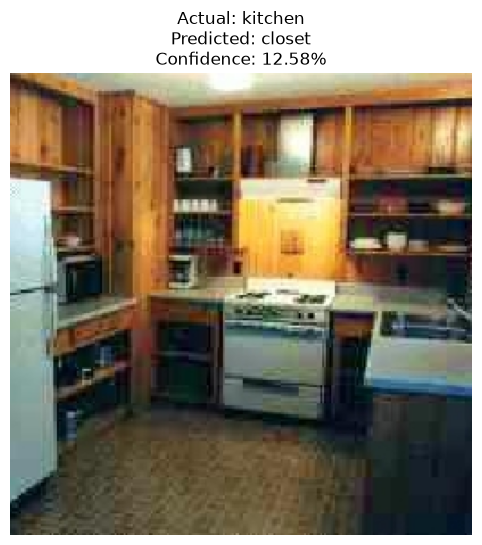

In [197]:
image = Image.open(
    sample_image
).convert("RGB")

plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()

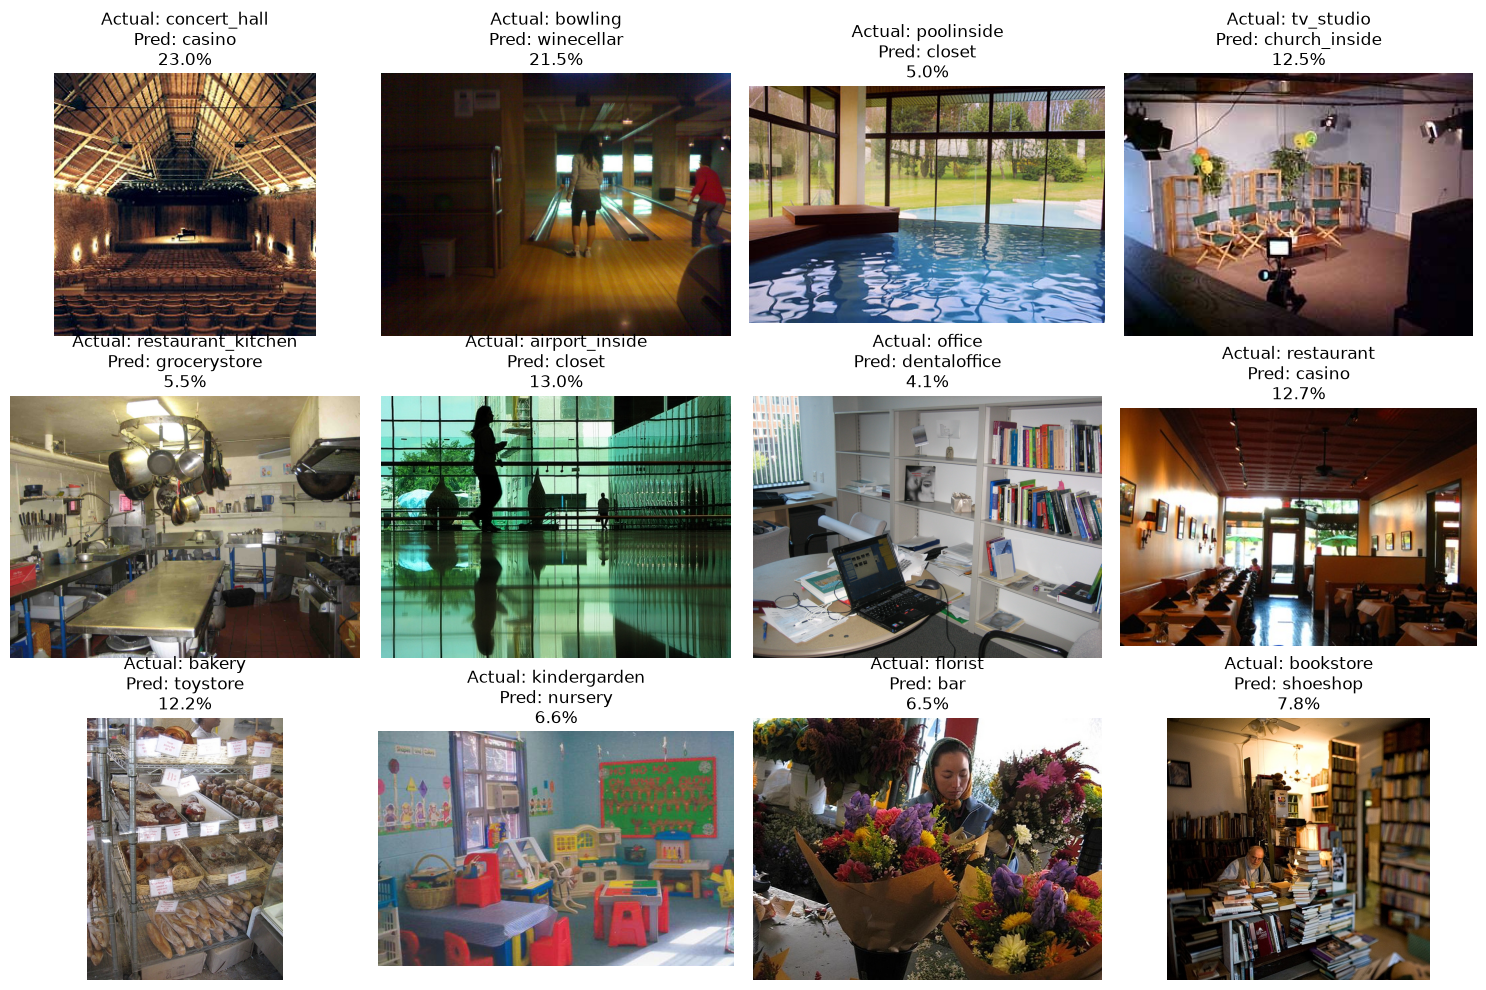

In [198]:
sample_indices = np.random.choice(
    len(test_df),
    12,
    replace=False
)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(sample_indices):

    image_file = test_df.iloc[
        idx
    ]["image_path"]

    actual = test_df.iloc[
        idx
    ]["class_name"]

    predicted, confidence = predict_image(
        image_file
    )

    image = Image.open(
        image_file
    ).convert("RGB")

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted}\n"
        f"{confidence * 100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()